In [1]:
import pandas as pd
import numpy as np 

In [2]:
nfl_data = pd.read_csv('testing_dataset/NFL Play by Play 2009-2017 (v4).csv')

np.random.seed(0)

/tmp/ipykernel_66238/3947063516.py:1: DtypeWarning: Columns (25,51) have mixed types. Specify dtype option on import or set low_memory=False.
  nfl_data = pd.read_csv('testing_dataset/NFL Play by Play 2009-2017 (v4).csv')


In [3]:
nfl_data.head()

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,NaN,15:00,15,3600.0,0.0,TEN,...,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,...,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,...,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009
3,2009-09-10,2009091000,1,1,3.0,13:35,14,3515.0,41.0,PIT,...,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2009-09-10,2009091000,1,1,4.0,13:27,14,3507.0,8.0,PIT,...,NaN,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,NaN,NaN,2009


In [4]:
# total number of rows
total_rows = nfl_data.shape[0]
print(f'Total number of rows: {total_rows}')

# total nujmber of columns
total_columns = nfl_data.shape[1]
print(f'Total number of columns: {total_columns}')

nfl_data.shape

Total number of rows: 407688
Total number of columns: 102


(407688, 102)

In [5]:
missing_values_count = nfl_data.isna().sum()

In [6]:
missing_values_count.index
# all columns contain atleast one missing value

Index(['Date', 'GameID', 'Drive', 'qtr', 'down', 'time', 'TimeUnder',
       'TimeSecs', 'PlayTimeDiff', 'SideofField',
       ...
       'yacEPA', 'Home_WP_pre', 'Away_WP_pre', 'Home_WP_post', 'Away_WP_post',
       'Win_Prob', 'WPA', 'airWPA', 'yacWPA', 'Season'],
      dtype='object', length=102)

In [7]:
missing_values_count.iloc[:11]

Date                0
GameID              0
Drive               0
qtr                 0
down            61154
time              224
TimeUnder           0
TimeSecs          224
PlayTimeDiff      444
SideofField       528
yrdln             840
dtype: int64

In [8]:
# Calculate the total number of values in the DataFrame,
# total rows multiplied by total columns
total_values = np.prod(nfl_data.shape)
# or  equivalently: total_values = nfl_data.size

# Calculate the total number of missing values in the DataFrame
total_missing = missing_values_count.sum()

print(f"total values: {total_values}\ntotal missing: {total_missing}")
print(f"percent missing: {(total_missing/total_values)*100:.2f}%")


total values: 41584176
total missing: 11505187
percent missing: 27.67%


### Figure out why the data is missing

        This is the point at which we get into the part of data science that I like to call "data intution", by which I mean "really looking at your data and trying to figure out why it is the way it is and how that will affect your analysis". It can be a frustrating part of data science, especially if you're newer to the field and don't have a lot of experience.

        For dealing with missing values, you'll need to use your intution to figure out why the value is missing.

        Is this value missing because it wasn't recorded or because it doesn't exist?


        If a value is missing becuase it doesn't exist (like the height of the oldest child of someone who doesn't have any children) then it doesn't make sense to try and guess what it might be. These values you probably do want to keep as NaN. On the other hand, if a value is missing because it wasn't recorded, then you can try to guess what it might have been based on the other values in that column and row. This is called imputation, and we'll learn how to do it next!



Let's work through an example. Looking at the number of missing values in the nfl_data dataframe, I notice that the column "TimesSec" has a lot of missing values in it:

In [9]:
missing_values_count.iloc[:10]

Date                0
GameID              0
Drive               0
qtr                 0
down            61154
time              224
TimeUnder           0
TimeSecs          224
PlayTimeDiff      444
SideofField       528
dtype: int64

        Drop missing values
        If you're in a hurry or don't have a reason to figure out why your values are missing, one option you have is to just remove any rows or columns that contain missing values. (Note: I don't generally recommend this approch for important projects! It's usually worth it to take the time to go through your data and really look at all the columns with missing values one-by-one to really get to know your dataset.)

        If you're sure you want to drop rows with missing values, pandas does have a handy function, dropna() to help you do this. Let's try it out on our NFL dataset!

In [10]:
nfl_data.dropna()

# Drop rows with any missing values, in this case
# it removed all our data because every row has at least one missing value

,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,...,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season


1️⃣ Functions that reduce or apply

    (apply, sum, mean, min, etc.)

    Here, axis means:

        ➝ “Move along this direction when doing the calculation.”

        axis=0: move down the rows, operate column by column

        axis=1: move across the columns, operate row by row

    df.apply(func, axis=1) “Apply the function to each row.”


2️⃣ Functions that remove labels

    (drop, dropna, rename, etc.)

    Here, axis means:

        ➝ “Which labels are you deleting / modifying?”

        Completely different idea.

        axis=0: remove rows

        axis=1: remove columns



df.dropna(axis=1) “Look at the columns and drop columns that contain NaN.”

In [11]:
# remove the whole column if any value is NaN
column_na_dropped = nfl_data.dropna(axis=1) 
column_na_dropped.head()

,Date,GameID,Drive,qtr,TimeUnder,ydstogo,ydsnet,PlayAttempted,Yards.Gained,sp,...,AwayTeam,Timeout_Indicator,posteam_timeouts_pre,HomeTimeouts_Remaining_Pre,AwayTimeouts_Remaining_Pre,HomeTimeouts_Remaining_Post,AwayTimeouts_Remaining_Post,ExPoint_Prob,TwoPoint_Prob,Season
0,2009-09-10,2009091000,1,1,15,0,0,1,39,0,...,TEN,0,3,3,3,3,3,0.0,0.0,2009
1,2009-09-10,2009091000,1,1,15,10,5,1,5,0,...,TEN,0,3,3,3,3,3,0.0,0.0,2009
2,2009-09-10,2009091000,1,1,15,5,2,1,-3,0,...,TEN,0,3,3,3,3,3,0.0,0.0,2009
3,2009-09-10,2009091000,1,1,14,8,2,1,0,0,...,TEN,0,3,3,3,3,3,0.0,0.0,2009
4,2009-09-10,2009091000,1,1,14,8,2,1,0,0,...,TEN,0,3,3,3,3,3,0.0,0.0,2009


In [12]:
# how much data was lost

print("Columns in original dataset: %d \n" % nfl_data.shape[1])
print("Columns with na's dropped: %d" % column_na_dropped.shape[1])

# We've lost quite a bit of data, but at this point we 
# have successfully removed all the NaN's from our data.

Columns in original dataset: 102 

Columns with na's dropped: 37


### Filling in missing values automatically


In [13]:
subset_nfl_data = nfl_data.loc[:, 'EPA': 'Season'].head()
subset_nfl_data

,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,NaN,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,NaN,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,NaN,NaN,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,NaN,NaN,2009


        We can use the Panda's fillna() function to fill in missing values in a dataframe for us. One option we have is to specify what we want the NaN values to be replaced with. Here, I'm saying that I would like to replace all the NaN values with 0.

In [14]:
subset_nfl_data.fillna(0)

,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,0.000000,0.000000,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,0.000000,0.000000,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,0.000000,0.000000,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,0.000000,0.000000,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,0.000000,0.000000,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,0.000000,0.000000,2009


        I could also be a bit more savvy and replace missing values with whatever value comes directly after it in the same column. (This makes a lot of sense for datasets where the observations have some sort of logical order to them.)

In [15]:
subset_nfl_data

,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,NaN,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,NaN,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,NaN,NaN,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,NaN,NaN,2009


In [16]:
# replace all NA's the value that comes directly after it in the same column, 
# then replace all the remaining na's with 0

# subset_nfl_data.fillna(method='bfill', axis=0).fillna(0)

# the above function will be depracated, it does the same.

subset_nfl_data.bfill(axis=0).fillna(0)

,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2.014474,-1.068169,1.146076,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,-0.032244,0.036899,2009
1,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,-1.402760,3.318841,-5.031425,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,0.106663,-0.156239,2009
3,-1.712583,3.318841,-5.031425,0.510793,0.489207,0.461217,0.538783,0.510793,-0.049576,0.106663,-0.156239,2009
4,2.097796,0.000000,0.000000,0.461217,0.538783,0.558929,0.441071,0.461217,0.097712,0.000000,0.000000,2009


These two are effectively the same:

        .bfill(axis=0) = “backward fill” along rows, only for missing values (NaN)
        → for each column, each NaN is replaced by the next non-NaN below it.

        .fillna(0) afterward = any NaNs that still remain (e.g., at the very bottom of a column, or in a column that was all NaNs) are set to 0.

So yes:

        bfill is specifically for filling NaN values using the next valid value.

        It does not change non-missing values.

        Chaining .bfill(...).fillna(0) does exactly what your comment says:

        Fill from the value that comes directly after it in the same column.

        Then replace any remaining NaNs with 0.

### Handling Missing Values

In [17]:
sf_permits = pd.read_csv('testing_dataset/Building_Permits.csv')

/tmp/ipykernel_66238/3108494454.py:1: DtypeWarning: Columns (22,32) have mixed types. Specify dtype option on import or set low_memory=False.
  sf_permits = pd.read_csv('testing_dataset/Building_Permits.csv')


In [18]:
np.random.seed(0) # only for purposes of reproducibility
sf_permits.shape

(198900, 43)

In [19]:
sf_permits.head()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,NaN,Ellis,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.785719256680785, -122.40852313194863)",1380611233945
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,NaN,Geary,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.78733980600732, -122.41063199757738)",1420164406718
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,NaN,Pacific,Av,...,1.0,constr type 1,1.0,constr type 1,NaN,3.0,Russian Hill,94109.0,"(37.7946573324287, -122.42232562979227)",1424856504716
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,NaN,Pacific,Av,...,5.0,wood frame (5),5.0,wood frame (5),NaN,3.0,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",1443574295566
4,201611283529,6,demolitions,11/28/2016,0342,001,950,NaN,Market,St,...,3.0,constr type 3,NaN,NaN,NaN,6.0,Tenderloin,94102.0,"(37.78315261897309, -122.40950883997789)",144548169992


# 2) How many missing data points do we have?

What percentage of the values in the dataset are missing?  Your answer should be a number between 0 and 100.  (If 1/4 of the values in the dataset are missing, the answer is 25.)

In [20]:
missing_data = sf_permits.isna().sum()
# check how many missing values per column, return a series of counts of missing values per column
missing_data[missing_data > 0].head()

Street Number Suffix    196684
Street Suffix             2768
Unit                    169421
Unit Suffix             196939
Description                290
dtype: int64

In [21]:
percent_missing = round((missing_data.sum() / sf_permits.size)*100, 2)

In [22]:
print(percent_missing)

26.26


# 3) Figure out why the data is missing

Look at the columns **"Street Number Suffix"** and **"Zipcode"** from the [San Francisco Building Permits dataset]. Both of these contain missing values. 
- Which, if either, are missing because they don't exist? 
- Which, if either, are missing because they weren't recorded?  

Once you have an answer, run the code cell below.

In [23]:
sf_permits.loc[:,['Street Number Suffix', 'Zipcode']].agg(['nunique'])
# returns a series of unique value counts for the specified columns

,Street Number Suffix,Zipcode
nunique,18,27


# 4) Drop missing values: rows

If you removed all of the rows of `sf_permits` with missing values, how many rows are left?

**Note**: Do not change the value of `sf_permits` when checking this.

In [24]:
filter_sf = sf_permits.dropna(axis=0)

In [25]:
filter_sf.shape
# no rows left after dropping all rows with any missing values, this means that
# every row has at least one missing value

(0, 43)

# 5) Drop missing values: columns

Now try removing all the columns with empty values.  
- Create a new DataFrame called `sf_permits_with_na_dropped` that has all of the columns with empty values removed.  
- How many columns were removed from the original `sf_permits` DataFrame? Use this number to set the value of the `dropped_columns` variable below.

In [26]:
sf_permits_with_na_dropped = sf_permits.dropna(axis=1)

In [27]:
sf_permits_with_na_dropped.shape

(198900, 12)

In [28]:
dropped_columns = sf_permits.shape[1] - sf_permits_with_na_dropped.shape[1]

In [29]:
dropped_columns

31

# 6) Fill in missing values automatically
Try replacing all the NaN's in the sf_permits data with the one that comes directly after it and then replacing any remaining NaN's with 0. Set the result to a new DataFrame sf_permits_with_na_imputed.

In [30]:
sf_permits.head()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,NaN,Ellis,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.785719256680785, -122.40852313194863)",1380611233945
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,NaN,Geary,St,...,3.0,constr type 3,NaN,NaN,NaN,3.0,Tenderloin,94102.0,"(37.78733980600732, -122.41063199757738)",1420164406718
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,NaN,Pacific,Av,...,1.0,constr type 1,1.0,constr type 1,NaN,3.0,Russian Hill,94109.0,"(37.7946573324287, -122.42232562979227)",1424856504716
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,NaN,Pacific,Av,...,5.0,wood frame (5),5.0,wood frame (5),NaN,3.0,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",1443574295566
4,201611283529,6,demolitions,11/28/2016,0342,001,950,NaN,Market,St,...,3.0,constr type 3,NaN,NaN,NaN,6.0,Tenderloin,94102.0,"(37.78315261897309, -122.40950883997789)",144548169992


In [31]:
sf_permits_with_na_imputed = sf_permits.bfill(axis=0).fillna(0)

In [32]:
sf_permits_with_na_imputed.head()

,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
0,201505065519,4,sign - erect,05/06/2015,0326,023,140,A,Ellis,St,...,3.0,constr type 3,1.0,constr type 1,Y,3.0,Tenderloin,94102.0,"(37.785719256680785, -122.40852313194863)",1380611233945
1,201604195146,4,sign - erect,04/19/2016,0306,007,440,A,Geary,St,...,3.0,constr type 3,1.0,constr type 1,Y,3.0,Tenderloin,94102.0,"(37.78733980600732, -122.41063199757738)",1420164406718
2,201605278609,3,additions alterations or repairs,05/27/2016,0595,203,1647,A,Pacific,Av,...,1.0,constr type 1,1.0,constr type 1,Y,3.0,Russian Hill,94109.0,"(37.7946573324287, -122.42232562979227)",1424856504716
3,201611072166,8,otc alterations permit,11/07/2016,0156,011,1230,A,Pacific,Av,...,5.0,wood frame (5),5.0,wood frame (5),Y,3.0,Nob Hill,94109.0,"(37.79595867909168, -122.41557405519474)",1443574295566
4,201611283529,6,demolitions,11/28/2016,0342,001,950,A,Market,St,...,3.0,constr type 3,1.0,constr type 1,Y,6.0,Tenderloin,94102.0,"(37.78315261897309, -122.40950883997789)",144548169992


## Scaling and Normalization

Scaling vs. Normalization: What's the difference?
    One of the reasons that it's easy to get confused between scaling and normalization is because the terms are sometimes used interchangeably and, to make it even more confusing, they are very similar! In both cases, you're transforming the values of numeric variables so that the transformed data points have specific helpful properties. The difference is that:

    in scaling, you're changing the range of your data, while
    in normalization, you're changing the shape of the distribution of your data.

In [33]:
# modules we'll use
import pandas as pd
import numpy as np

# for Box-Cox Transformation
from scipy import stats

# for min_max scaling
from mlxtend.preprocessing import minmax_scaling

# plotting modules
import seaborn as sns
import matplotlib.pyplot as plt

# set seed for reproducibility
np.random.seed(0)

### Scaling

        This means that you're transforming your data so that it fits within a specific scale, like 0-100 or 0-1. You want to scale data when you're using methods based on measures of how far apart data points are, like support vector machines (SVM) or k-nearest neighbors (KNN). With these algorithms, a change of "1" in any numeric feature is given the same importance.

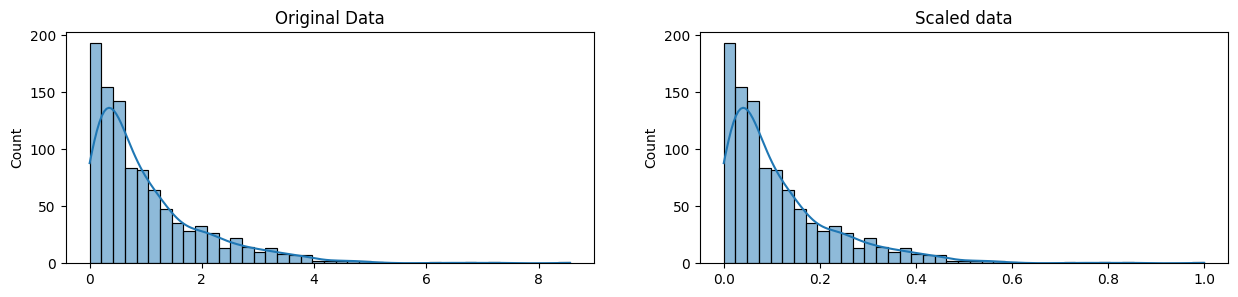

In [34]:
# generate 1000 data points randomly drawn from an exponential distribution
original_data = np.random.exponential(size=1000)

# mix-max scale the data between 0 and 1
scaled_data = minmax_scaling(original_data, columns=[0])

# plot both together to compare
fig, ax = plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)

ax[0].set_title("Original Data")
sns.histplot(scaled_data, ax=ax[1], kde=True, legend=False)

ax[1].set_title("Scaled data")
plt.show()

### Normalization
        Scaling just changes the range of your data. Normalization is a more radical transformation. The point of normalization is to change your observations so that they can be described as a normal distribution.

        Normal distribution: Also known as the "bell curve", this is a specific statistical distribution where a roughly equal observations fall above and below the mean, the mean and the median are the same, and there are more observations closer to the mean. The normal distribution is also known as the Gaussian distribution.

        In general, you'll normalize your data if you're going to be using a machine learning or statistics technique that assumes your data is normally distributed. Some examples of these include linear discriminant analysis (LDA) and Gaussian naive Bayes. (Pro tip: any method with "Gaussian" in the name probably assumes normality.)

        The method we're using to normalize here is called the Box-Cox Transformation. Let's take a quick peek at what normalizing some data looks like:

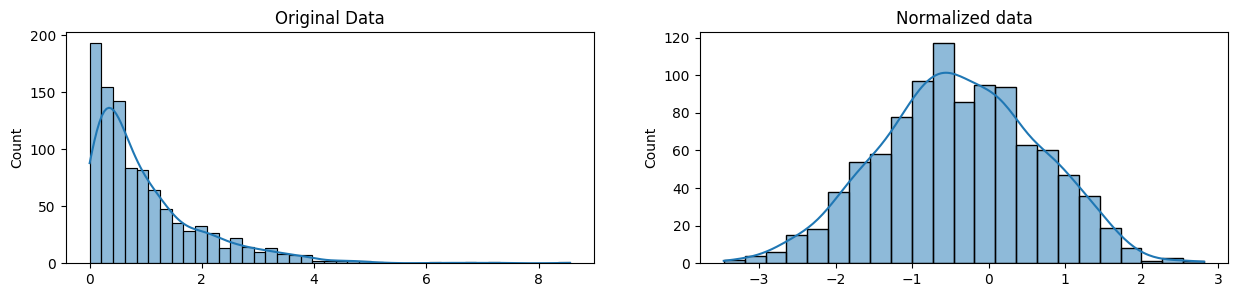

In [35]:
# normalize the exponential data with boxcox
normalized_data = stats.boxcox(original_data)

# plot both together to compare
fig, ax=plt.subplots(1, 2, figsize=(15, 3))
sns.histplot(original_data, ax=ax[0], kde=True, legend=False)
ax[0].set_title("Original Data")
sns.histplot(normalized_data[0], ax=ax[1], kde=True, legend=False)
ax[1].set_title("Normalized data")
plt.show()

Notice that the shape of our data has changed. Before normalizing it was almost L-shaped. But after normalizing it looks more like the outline of a bell (hence "bell curve").

## Exercise Practice Scaling

In [36]:
# for Box-Cox Transformation
from scipy import stats

# for min_max scaling
from mlxtend.preprocessing import minmax_scaling

# plotting modules
import seaborn as sns
import matplotlib.pyplot as plt

# set seed for reproducibility
np.random.seed(0)

In [37]:
kickstarters_2017 = pd.read_csv('testing_dataset/ks-projects-201801.csv')

Let's start by scaling the goals of each campaign, which is how much money they were asking for.  After scaling, all values lie between 0 and 1.

In [38]:
# select the usd_goal_real column
original_data = pd.DataFrame(kickstarters_2017.usd_goal_real)

# scale the goals from 0 to 1
# this uses the mlxtend minmax_scaling function
# heres how it works, it scales the values in the specified 
# column(s) to a range between 0 and 1
scaled_data = minmax_scaling(original_data, columns=['usd_goal_real'])

print('Original data\nPreview:\n', original_data.head())
print('Minimum value:', float(original_data.min()),
      '\nMaximum value:', float(original_data.max()))
print('_'*30)

print('\nScaled data\nPreview:\n', scaled_data.head())
print('Minimum value:', float(scaled_data.min()),
      '\nMaximum value:', float(scaled_data.max()))

Original data
Preview:
    usd_goal_real
0        1533.95
1       30000.00
2       45000.00
3        5000.00
4       19500.00
Minimum value: 0.01 
Maximum value: 166361390.71
______________________________

Scaled data
Preview:
    usd_goal_real
0       0.000009
1       0.000180
2       0.000270
3       0.000030
4       0.000117
Minimum value: 0.0 
Maximum value: 1.0


/tmp/ipykernel_66238/3449430.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Minimum value:', float(original_data.min()),
/tmp/ipykernel_66238/3449430.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  '\nMaximum value:', float(original_data.max()))
/tmp/ipykernel_66238/3449430.py:16: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print('Minimum value:', float(scaled_data.min()),
/tmp/ipykernel_66238/3449430.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  '\nMaximum value:', float(scaled_data.max()))


Use original_goal_data to create a new DataFrame scaled_goal_data with values scaled between 0 and 1. You must use the minmax_scaling() function.

In [39]:
# select the goals column into a pd
original_goal_data = pd.DataFrame(kickstarters_2017.goal)

# original_goal_data is the argument for minmax_scaling and columns=['goal']
# ['goal'] is in a list because minmax_scaling expects a list of column names
scaled_goal_data = minmax_scaling(original_goal_data, columns=['goal'])


In [40]:
original_goal_data.head()

,goal
0,1000.0
1,30000.0
2,45000.0
3,5000.0
4,19500.0


In [41]:
scaled_goal_data.head()

,goal
0,0.000010
1,0.000300
2,0.000450
3,0.000050
4,0.000195


# 2) Practice normalization

Now you'll practice normalization. We begin by normalizing the amount of money pledged to each campaign.

In [42]:
# get the index of all positive pledges (Box-Cox only takes positive values)
index_of_positive_pledges = kickstarters_2017.usd_pledged_real > 0

# get only positive pledges (using their indexes)
positive_pledges = kickstarters_2017.usd_pledged_real.loc[index_of_positive_pledges]

# normalize the pledges (w/ Box-Cox)
normalized_pledges = pd.Series(stats.boxcox(positive_pledges)[0], 
                               name='usd_pledged_real', index=positive_pledges.index)

print('Original data\nPreview:\n', positive_pledges.head())
print('Minimum value:', float(positive_pledges.min()),
      '\nMaximum value:', float(positive_pledges.max()))
print('_'*30)

print('\nNormalized data\nPreview:\n', normalized_pledges.head())
print('Minimum value:', float(normalized_pledges.min()),
      '\nMaximum value:', float(normalized_pledges.max()))

Original data
Preview:
 1     2421.0
2      220.0
3        1.0
4     1283.0
5    52375.0
Name: usd_pledged_real, dtype: float64
Minimum value: 0.45 
Maximum value: 20338986.27
______________________________

Normalized data
Preview:
 1    10.165143
2     6.468598
3     0.000000
4     9.129277
5    15.836853
Name: usd_pledged_real, dtype: float64
Minimum value: -0.7779954120722625 
Maximum value: 30.69054040635257


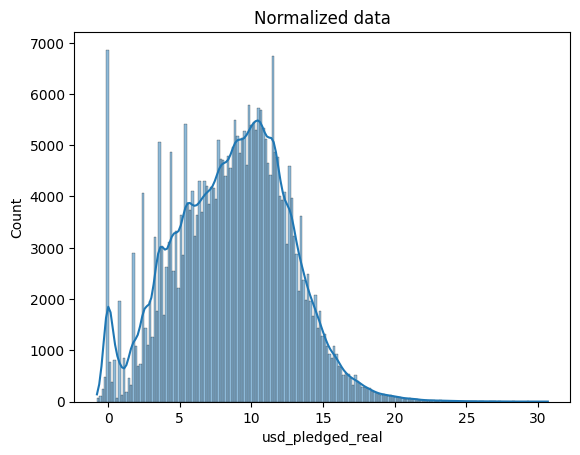

In [43]:
# plot normalized data
ax = sns.histplot(normalized_pledges, kde=True)
ax.set_title("Normalized data")
plt.show()

We used the "usd_pledged_real" column. Follow the same process to normalize the "pledged" column. 

stats.boxcox(...) returns numpy output (not a pandas Series). In your notebook SciPy returns a tuple (transformed_array, lmbda) so the code takes the transformed values with [0], then wraps them in a pandas Series and re-uses the original index and a name.

Step-by-step:

stats.boxcox(all_positive_pledges) → (transformed_array, fitted_lambda)
stats.boxcox(...)[0] → the transformed_array (1-D numpy array)
pd.Series(..., name='pledges', index=all_positive_pledges.index) → convert that array back to a pandas Series with the same index as the original filtered Series and give it the name "pledges" (useful for plotting / joining back to the DataFrame).
If you prefer clearer code:

```python
# unpack explicitly and preserve index
transformed, fitted_lambda = stats.boxcox(all_positive_pledges)
normalized_pledges = pd.Series(transformed, index=all_positive_pledges.index, name='pledges')
```

In [44]:
all_positive_pledges = kickstarters_2017.pledged.loc[kickstarters_2017.pledged > 0]

print(all_positive_pledges.head(10))

normalized_pledges = pd.Series(stats.boxcox(all_positive_pledges)[0], 
                               name='pledges', index=all_positive_pledges.index)



1      2421.00
2       220.00
3         1.00
4      1283.00
5     52375.00
6      1205.00
7       453.00
8      8233.00
9      6240.57
11    12700.00
Name: pledged, dtype: float64


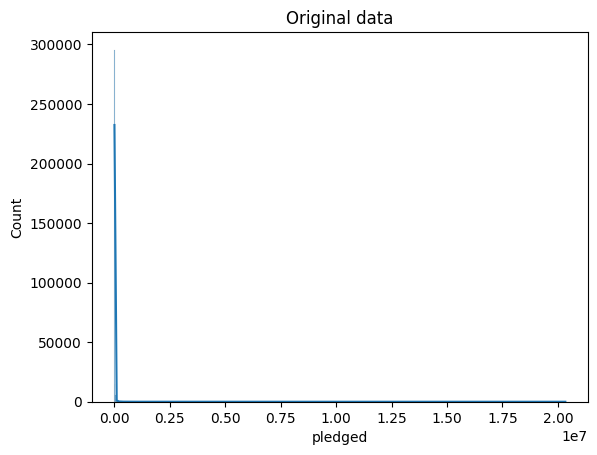

In [45]:
ax = sns.histplot(all_positive_pledges, kde=True)
ax.set_title("Original data")
plt.show()

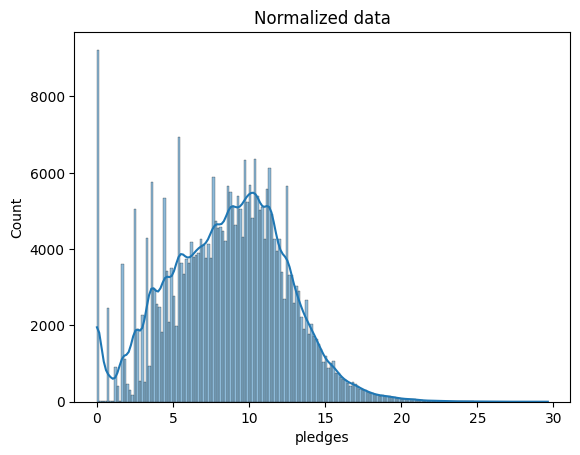

In [46]:
ax = sns.histplot(normalized_pledges, kde=True)
ax.set_title("Normalized data")
plt.show()

Project Temporary on Halt